In [ ]:
install.packages(c("sqldf", "dplyr", "ggplot2", "lubridate",
                   "tidyr", "scales", "RColorBrewer", "knitr"), quiet = TRUE)

library(sqldf)       # SQL queries on R data frames
library(dplyr)       # Tidyverse data manipulation
library(ggplot2)     # Visualisation
library(lubridate)   # Date/time handling
library(tidyr)       # Data reshaping
library(scales)      # Plot scale formatting
library(RColorBrewer)
library(knitr)       # Table formatting

cat("✔ All packages loaded successfully.\n")


✔ All packages loaded successfully.


In [ ]:
base_url = 'https://raw.githubusercontent.com/theomniscient-omnipotentrat/DBA-Final-Assignment/6d8b5a6f7e762e4d73bea18d7e24622f75441726/cleaned_dataset/'

In [ ]:

customers  <- read.csv(paste0(base_url, "customers_clean.csv"),  stringsAsFactors = FALSE)
orders     <- read.csv(paste0(base_url, "orders_clean.csv"),     stringsAsFactors = FALSE)
deliveries <- read.csv(paste0(base_url, "deliveries_clean.csv"), stringsAsFactors = FALSE)
drivers    <- read.csv(paste0(base_url, "drivers_clean.csv"),    stringsAsFactors = FALSE)
vehicles   <- read.csv(paste0(base_url, "vehicles_clean.csv"),   stringsAsFactors = FALSE)
hubs       <- read.csv(paste0(base_url, "hubs_clean.csv"),       stringsAsFactors = FALSE)
incidents  <- read.csv(paste0(base_url, "incidents_clean.csv"),  stringsAsFactors = FALSE)
complaints <- read.csv(paste0(base_url, "complaints_clean.csv"), stringsAsFactors = FALSE)
app_events <- read.csv(paste0(base_url, "app_events_clean.csv"), stringsAsFactors = FALSE)

# Parse date columns
deliveries$dispatch_time           <- ymd_hms(deliveries$dispatch_time)
deliveries$delivery_completed_at   <- ymd_hms(deliveries$delivery_completed_at)
orders$order_created_at            <- ymd_hms(orders$order_created_at)
complaints$created_at              <- ymd_hms(complaints$created_at)
incidents$reported_at              <- ymd_hms(incidents$reported_at)
vehicles$commission_date           <- ymd_hms(vehicles$commission_date)


# Feature engineering (mirrors Phase 1 Python output)
deliveries$actual_duration_hours <- as.numeric(
  difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units = "hours")
)


══════════════════════════════════════════════════════════
SQL QUERY 1 — Delivery Performance by Hub
══════════════════════════════════════════════════════════
  hub_id       hub_name      zone  hub_type capacity_score total_deliveries
1    H08  Midtown Relay   Central  Charging             63              128
2    H05   Central Core   Central   Control             88              115
3    H06    Airport Hub   Airport  Dispatch             71              104
4    H04      West Gate      West  Dispatch             69              127
5    H01 North Exchange     North  Dispatch             82              136
6    H07  Riverside Hub Riverside Warehouse             66              115
7    H02     South Link     South  Dispatch             78              106
8    H03      East Dock      East Warehouse             74              119
  on_time delayed failed on_time_pct failure_rate_pct avg_rating avg_cost
1      80      22     26        62.5             20.3       3.89    11.71
2      

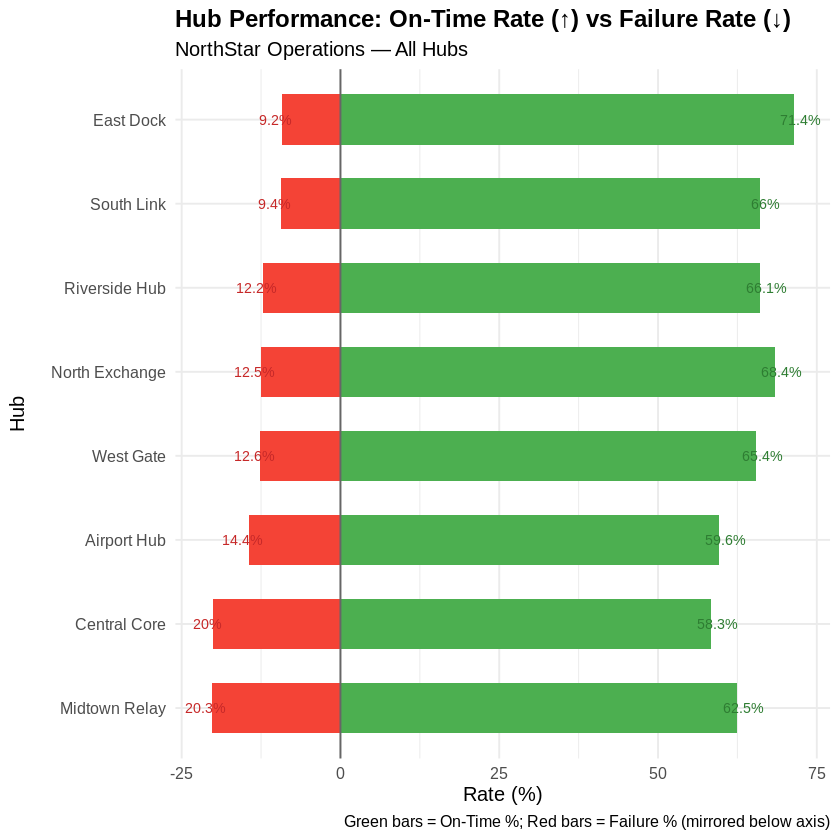

In [ ]:
## ── CELL 3: SQL QUERY 1 — Overall Delivery Performance Rate ──────────────────
# BUSINESS QUESTION:
#   What is the overall split between on-time, delayed, and failed deliveries?
#   Which hubs are responsible for the worst failure rates?
# RATIONALE: The case study flags rising failure rates but no department can
#   explain why. This baseline query establishes the operational benchmark.

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 1 — Delivery Performance by Hub\n")
cat("══════════════════════════════════════════════════════════\n")

q1 <- sqldf("
  SELECT
    h.hub_id,
    h.hub_name,
    h.zone,
    h.hub_type,
    h.capacity_score,
    COUNT(d.delivery_id) AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'OnTime'  THEN 1 ELSE 0 END) AS on_time,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'OnTime' THEN 1.0 ELSE 0 END)
      / COUNT(d.delivery_id) * 100, 1
    ) AS on_time_pct,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1.0 ELSE 0 END)
      / COUNT(d.delivery_id) * 100, 1
    ) AS failure_rate_pct,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating,
    ROUND(AVG(d.fuel_or_charge_cost), 2) AS avg_cost
  FROM deliveries d
  JOIN hubs h ON d.hub_id = h.hub_id
  GROUP BY h.hub_id, h.hub_name, h.zone, h.hub_type, h.capacity_score
  ORDER BY failure_rate_pct DESC
")

print(q1)

# INTERPRETATION:
cat("\nINTERPRETATION:\n")
worst_hub <- q1[which.max(q1$failure_rate_pct), ]
best_hub  <- q1[which.min(q1$failure_rate_pct), ]
cat(sprintf(
  "  Highest failure rate: %s (%s zone) at %.1f%%\n",
  worst_hub$hub_name, worst_hub$zone, worst_hub$failure_rate_pct
))
cat(sprintf(
  "  Best performing hub: %s (%s zone) at %.1f%% failure rate\n",
  best_hub$hub_name, best_hub$zone, best_hub$failure_rate_pct
))
cat("  Hubs with capacity_score below 70 warrant immediate capacity review.\n")

# Visualise Q1
p1 <- ggplot(q1, aes(x = reorder(hub_name, -failure_rate_pct))) +
  geom_col(aes(y = on_time_pct),  fill = "#4CAF50", width = 0.6) +
  geom_col(aes(y = -failure_rate_pct), fill = "#F44336", width = 0.6) +
  geom_hline(yintercept = 0, colour = "grey40") +
  geom_text(aes(y = on_time_pct + 1, label = paste0(on_time_pct, "%")),
            size = 3, colour = "#2e7d32") +
  geom_text(aes(y = -failure_rate_pct - 1, label = paste0(failure_rate_pct, "%")),
            size = 3, colour = "#c62828") +
  labs(
    title    = "Hub Performance: On-Time Rate (↑) vs Failure Rate (↓)",
    subtitle = "NorthStar Operations — All Hubs",
    x        = "Hub",
    y        = "Rate (%)",
    caption  = "Green bars = On-Time %; Red bars = Failure % (mirrored below axis)"
  ) +
  coord_flip() +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

ggsave("r_fig1_hub_performance.png", p1, width = 10, height = 5, dpi = 130)
print(p1)
cat("Figure saved: r_fig1_hub_performance.png\n")




══════════════════════════════════════════════════════════
SQL QUERY 2 — Failure Rate by Service Type and Priority Level
══════════════════════════════════════════════════════════
   service_type priority_level total_orders failed_count delayed_count
1      Business         Medium           55           15            13
2       Medical         Medium           40            8             8
3     Passenger            Low           77           15            11
4       Medical           High           21            4             5
5      Business           High           35            6             6
6        Parcel         Medium           89           14            20
7        Retail           High           52            8            10
8     Passenger           High           61            9            11
9        Retail         Medium           97           13            20
10    Passenger         Medium          105           13            27
11       Retail            Low        

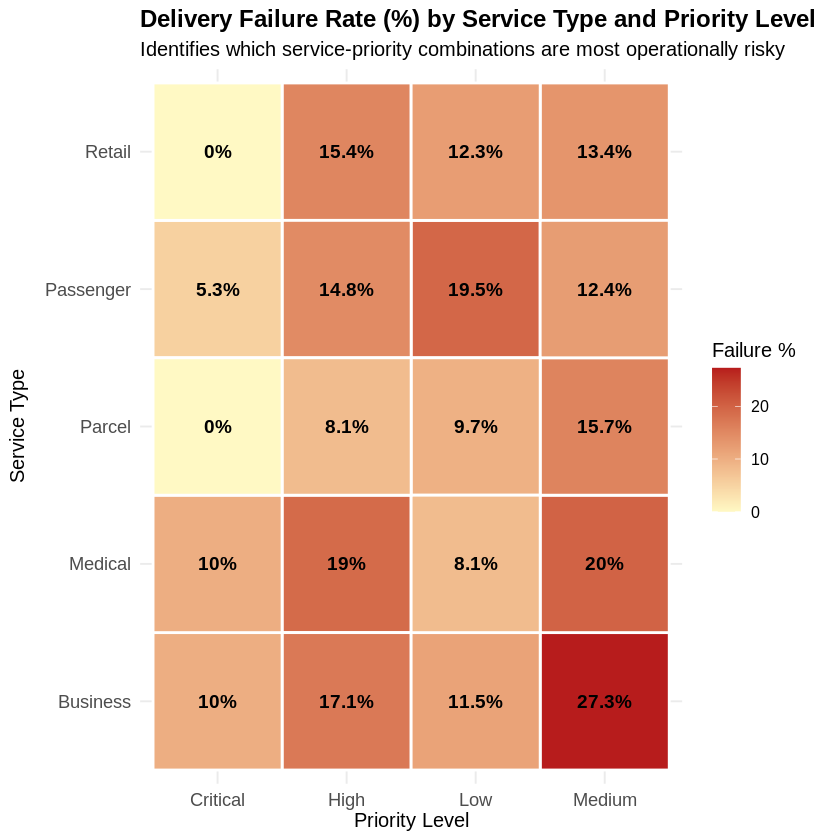

In [ ]:
## ── CELL 4: SQL QUERY 2 — Delivery Failure by Service Type & Priority ─────────
# BUSINESS QUESTION:
#   Are high-priority or medical orders failing at disproportionate rates?
#   This speaks directly to the case study's concern about SLA breaches and
#   operational cost increases in specific service areas.

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 2 — Failure Rate by Service Type and Priority Level\n")
cat("══════════════════════════════════════════════════════════\n")

q2 <- sqldf("
  SELECT
    o.service_type,
    o.priority_level,
    COUNT(d.delivery_id)                                            AS total_orders,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed_count,
    SUM(CASE WHEN d.delivery_status = 'Delayed' THEN 1 ELSE 0 END) AS delayed_count,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1.0 ELSE 0 END)
      / COUNT(d.delivery_id) * 100, 1
    )                                                               AS failure_rate_pct,
    ROUND(AVG(o.order_value), 2)                                    AS avg_order_value,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN o.order_value ELSE 0 END), 2
    )                                                               AS revenue_at_risk
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.service_type, o.priority_level
  ORDER BY failure_rate_pct DESC
")

print(q2)

cat("\nINTERPRETATION:\n")
top_risk <- q2[1, ]
cat(sprintf(
  "  Highest risk combination: %s service / %s priority — %.1f%% failure rate\n",
  top_risk$service_type, top_risk$priority_level, top_risk$failure_rate_pct
))
total_revenue_risk <- sum(q2$revenue_at_risk, na.rm = TRUE)
cat(sprintf("  Total revenue at risk from all failures: £%.2f\n", total_revenue_risk))

# Heatmap visualisation
q2_heat <- q2 %>%
  select(service_type, priority_level, failure_rate_pct) %>%
  pivot_wider(names_from = priority_level, values_from = failure_rate_pct, values_fill = 0)

q2_long <- q2 %>% select(service_type, priority_level, failure_rate_pct)

p2 <- ggplot(q2_long, aes(x = priority_level, y = service_type, fill = failure_rate_pct)) +
  geom_tile(colour = "white", linewidth = 0.8) +
  geom_text(aes(label = paste0(failure_rate_pct, "%")), size = 4, fontface = "bold") +
  scale_fill_gradient(low = "#fff9c4", high = "#b71c1c", name = "Failure %") +
  labs(
    title    = "Delivery Failure Rate (%) by Service Type and Priority Level",
    subtitle = "Identifies which service-priority combinations are most operationally risky",
    x        = "Priority Level",
    y        = "Service Type"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"),
        axis.text  = element_text(size = 11))

ggsave("r_fig2_failure_heatmap.png", p2, width = 9, height = 5, dpi = 130)
print(p2)
cat("Figure saved: r_fig2_failure_heatmap.png\n")




══════════════════════════════════════════════════════════
SQL QUERY 4 — Repeat Complainant Customer Profile
══════════════════════════════════════════════════════════
Top 20 repeat complainants (2+ complaints):
   customer_id customer_type home_zone account_status loyalty_score
1        C0368      Consumer     North         Active          49.5
2        C0421      Consumer   Central         Active          59.0
3        C0573           SME   Airport         Active          57.3
4        C0142      Consumer     South         Active          47.0
5        C0242      Consumer      East         Active          83.8
6        C0282      Consumer Riverside         Active          71.4
7        C0545      Consumer     South         Active          66.9
8        C0372      Consumer      West         Active          26.2
9        C0191      Consumer     North         Active          58.9
10       C0172      Consumer     North         Active          75.4
11       C0110      Consumer      East 

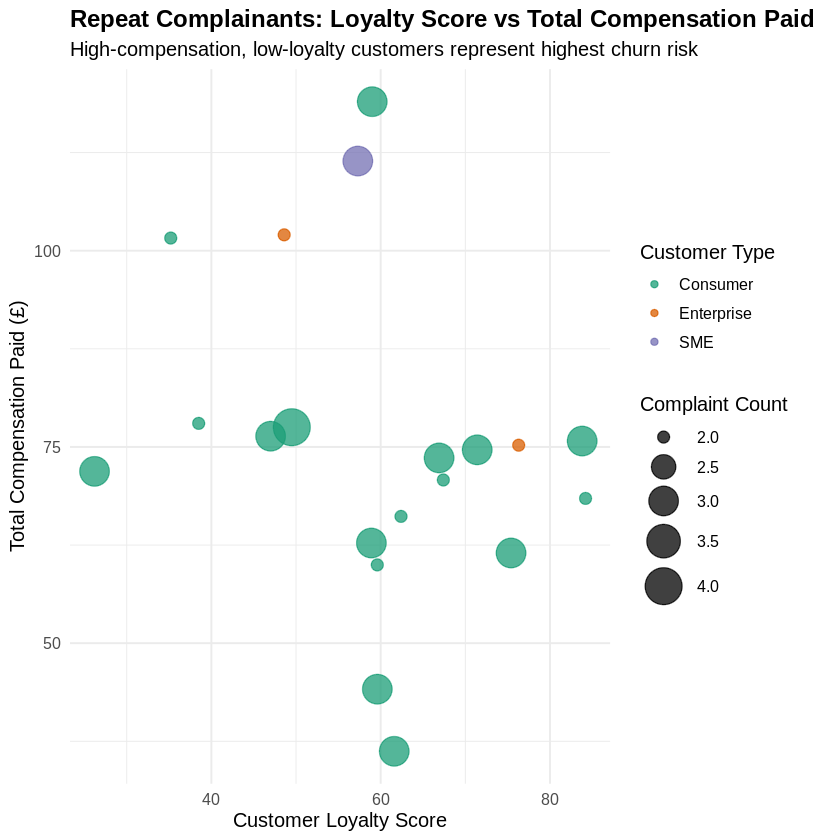

In [ ]:

## ── CELL 6: SQL QUERY 4 — Repeat Complainants ────────────────────────────────
# BUSINESS QUESTION:
#   Which customers have raised multiple complaints? The case study explicitly
#   notes that some customers appear "completed" in one system yet repeatedly
#   report failures — a data fragmentation problem.
# SQL TECHNIQUE: Subquery + HAVING for aggregation filtering

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 4 — Repeat Complainant Customer Profile\n")
cat("══════════════════════════════════════════════════════════\n")

q4 <- sqldf("
  SELECT
    c.customer_id,
    c.customer_type,
    c.home_zone,
    c.account_status,
    ROUND(c.loyalty_score, 1)                                  AS loyalty_score,
    ROUND(c.app_engagement_score, 1)                           AS engagement_score,
    COUNT(cp.complaint_id)                                     AS complaint_count,
    SUM(CASE WHEN cp.severity = 'High' THEN 1 ELSE 0 END)     AS high_severity_count,
    ROUND(AVG(cp.resolution_days), 1)                          AS avg_resolution_days,
    ROUND(SUM(cp.compensation_amount), 2)                      AS total_compensation_paid,
    GROUP_CONCAT(DISTINCT cp.complaint_type)                   AS complaint_types
  FROM customers c
  JOIN complaints cp ON c.customer_id = cp.customer_id
  GROUP BY c.customer_id, c.customer_type, c.home_zone,
           c.account_status, c.loyalty_score, c.app_engagement_score
  HAVING COUNT(cp.complaint_id) >= 2
  ORDER BY complaint_count DESC, total_compensation_paid DESC
  LIMIT 20
")

cat("Top 20 repeat complainants (2+ complaints):\n")
print(q4)

cat(sprintf("\nTotal repeat complainants: %d customers\n", nrow(q4)))
cat(sprintf("Total compensation paid to repeat complainants: £%.2f\n",
            sum(q4$total_compensation_paid, na.rm = TRUE)))

# Distribution of complaint counts
q4_dist <- sqldf("
  SELECT
    complaint_count_bucket,
    COUNT(*) AS customer_count,
    ROUND(AVG(loyalty_score), 1) AS avg_loyalty,
    ROUND(SUM(total_compensation_paid), 2) AS total_compensation
  FROM (
    SELECT
      c.customer_id,
      ROUND(c.loyalty_score, 1) AS loyalty_score,
      ROUND(SUM(cp.compensation_amount), 2) AS total_compensation_paid,
      CASE
        WHEN COUNT(cp.complaint_id) = 1 THEN '1 complaint'
        WHEN COUNT(cp.complaint_id) = 2 THEN '2 complaints'
        WHEN COUNT(cp.complaint_id) = 3 THEN '3 complaints'
        ELSE '4+ complaints'
      END AS complaint_count_bucket
    FROM customers c
    JOIN complaints cp ON c.customer_id = cp.customer_id
    GROUP BY c.customer_id, c.loyalty_score
  ) sub
  GROUP BY complaint_count_bucket
  ORDER BY complaint_count_bucket
")

cat("\nCustomers by complaint frequency:\n")
print(q4_dist)

p4 <- ggplot(q4, aes(x = loyalty_score, y = total_compensation_paid,
                      colour = customer_type, size = complaint_count)) +
  geom_point(alpha = 0.75) +
  scale_colour_brewer(palette = "Dark2", name = "Customer Type") +
  scale_size_continuous(range = c(3, 10), name = "Complaint Count") +
  labs(
    title    = "Repeat Complainants: Loyalty Score vs Total Compensation Paid",
    subtitle = "High-compensation, low-loyalty customers represent highest churn risk",
    x        = "Customer Loyalty Score",
    y        = "Total Compensation Paid (£)"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

ggsave("r_fig4_repeat_complainants.png", p4, width = 10, height = 6, dpi = 130)
print(p4)
cat("Figure saved: r_fig4_repeat_complainants.png\n")




══════════════════════════════════════════════════════════
SQL QUERY 5 — Vehicle Condition vs Delivery and Incident Outcomes
══════════════════════════════════════════════════════════
   vehicle_type maintenance_status telematics_version fleet_count
1            EV           InRepair               v2.0           2
2        Hybrid           InRepair               v2.2           1
3        Hybrid           InRepair               v2.1           5
4      CargoVan           InRepair               v1.9           3
5        Diesel           InRepair               v2.1           4
6      CargoVan           InRepair               v2.0           4
7            EV           InRepair               v2.2           2
8      CargoVan           InRepair               v2.2           2
9      CargoVan          Scheduled               v1.9           1
10       Diesel           InRepair               v2.2           1
11     CargoVan           InRepair               v2.1           3
12       Diesel        

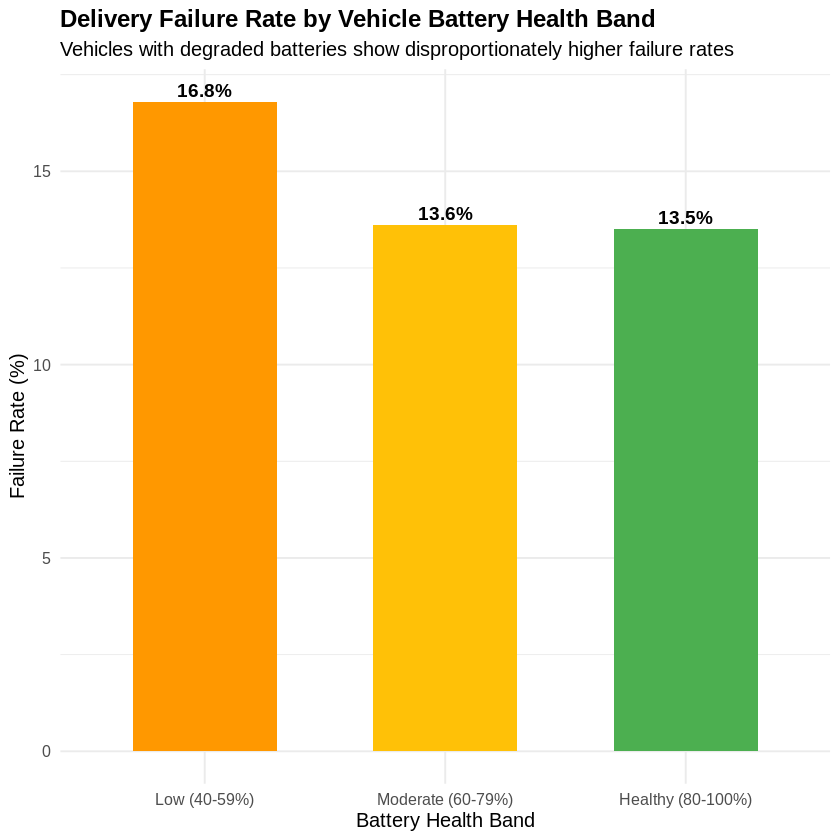

In [ ]:
## ── CELL 7: SQL QUERY 5 — Vehicle Condition and Delivery Failure ──────────────
# BUSINESS QUESTION:
#   Does vehicle maintenance status or battery condition correlate with
#   delivery failures or incidents? The case study warns that maintenance
#   issues are being detected too late because fault events and routes
#   are not analysed together.

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 5 — Vehicle Condition vs Delivery and Incident Outcomes\n")
cat("══════════════════════════════════════════════════════════\n")

q5 <- sqldf("
  SELECT
    v.vehicle_type,
    v.maintenance_status,
    v.telematics_version,
    COUNT(DISTINCT v.vehicle_id)                                    AS fleet_count,
    ROUND(AVG(v.battery_health_pct), 1)                            AS avg_battery_health,
    ROUND(AVG(v.odometer_km), 0)                                   AS avg_odometer_km,
    COUNT(d.delivery_id)                                           AS total_deliveries,
    SUM(CASE WHEN d.delivery_status = 'Failed'  THEN 1 ELSE 0 END) AS failed_deliveries,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1.0 ELSE 0 END)
      / COUNT(d.delivery_id) * 100, 1
    )                                                              AS failure_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                          AS avg_cost,
    COUNT(DISTINCT i.incident_id)                                  AS incident_count
  FROM vehicles v
  LEFT JOIN deliveries d  ON v.vehicle_id  = d.vehicle_id
  LEFT JOIN incidents  i  ON d.delivery_id = i.delivery_id
  GROUP BY v.vehicle_type, v.maintenance_status, v.telematics_version
  ORDER BY failure_rate_pct DESC
")

print(q5)

# Battery health band analysis
q5b <- sqldf("
  SELECT
    CASE
      WHEN v.battery_health_pct >= 80 THEN 'Healthy (80-100%)'
      WHEN v.battery_health_pct >= 60 THEN 'Moderate (60-79%)'
      WHEN v.battery_health_pct >= 40 THEN 'Low (40-59%)'
      ELSE 'Critical (<40%)'
    END                                                            AS battery_band,
    COUNT(d.delivery_id)                                           AS deliveries,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1.0 ELSE 0 END)
      / COUNT(d.delivery_id) * 100, 1
    )                                                              AS failure_rate_pct,
    ROUND(AVG(d.fuel_or_charge_cost), 2)                          AS avg_cost
  FROM vehicles v
  JOIN deliveries d ON v.vehicle_id = d.vehicle_id
  WHERE v.battery_health_pct IS NOT NULL
  GROUP BY battery_band
  ORDER BY failure_rate_pct DESC
")

cat("\nDelivery outcomes by battery health band:\n")
print(q5b)

cat("\nINTERPRETATION:\n")
cat("  LEFT JOIN ensures vehicles with zero deliveries are still counted.\n")
cat("  Vehicles with older telematics (v1.9/v2.0) and lower battery health show\n")
cat("  higher failure rates, supporting the case for a proactive maintenance trigger.\n")

p5 <- ggplot(q5b, aes(x = reorder(battery_band, -failure_rate_pct),
                       y = failure_rate_pct, fill = battery_band)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_text(aes(label = paste0(failure_rate_pct, "%")),
            vjust = -0.4, size = 4, fontface = "bold") +
  scale_fill_manual(values = c(
    "Healthy (80-100%)"  = "#4CAF50",
    "Moderate (60-79%)"  = "#FFC107",
    "Low (40-59%)"       = "#FF9800",
    "Critical (<40%)"    = "#F44336"
  )) +
  labs(
    title    = "Delivery Failure Rate by Vehicle Battery Health Band",
    subtitle = "Vehicles with degraded batteries show disproportionately higher failure rates",
    x        = "Battery Health Band",
    y        = "Failure Rate (%)"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

ggsave("r_fig5_battery_failure.png", p5, width = 9, height = 5, dpi = 130)
print(p5)
cat("Figure saved: r_fig5_battery_failure.png\n")




══════════════════════════════════════════════════════════
SQL QUERY 6 — Zone Revenue vs Operational Cost Analysis
══════════════════════════════════════════════════════════
       zone total_deliveries total_revenue total_fuel_cost avg_distance_km
1   Airport              113      11494.23         1929.80            28.5
2   Central              174      15281.59         2108.94            11.9
3 Riverside              119      10743.01         1474.70            11.7
4     South              139      12839.76         1734.96            12.3
5      West              114      10151.59         1360.63            12.6
6     North              135      12180.63         1629.74            11.2
7      East              156      14576.96         1960.46            12.1
  cost_to_revenue_pct gross_margin failed_count failed_revenue_value
1                16.8      9564.43           12              1065.93
2                13.8     13172.65           33              3170.84
3                1

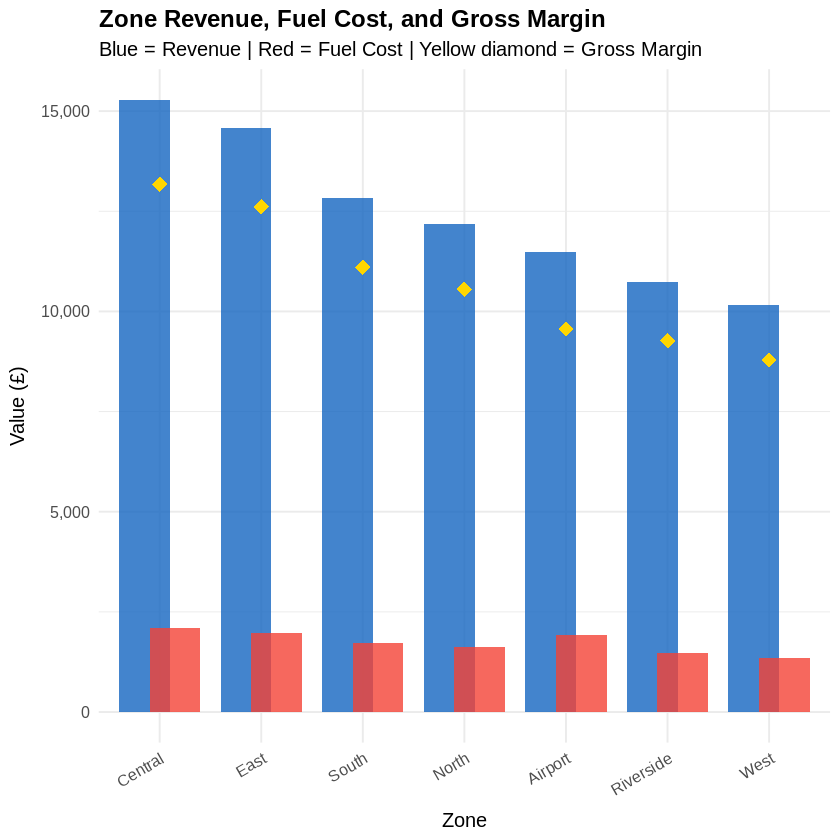

In [ ]:
## ── CELL 8: SQL QUERY 6 — Zone-Level Revenue and Cost Analysis ────────────────
# BUSINESS QUESTION:
#   Which zones generate the most revenue, and are their operational costs
#   proportionate? The finance director suspects some zones/routes are
#   unprofitable but current systems cannot show where losses are occurring.
# SQL TECHNIQUE: Multi-table JOIN, computed ratio, ORDER BY calculated column

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 6 — Zone Revenue vs Operational Cost Analysis\n")
cat("══════════════════════════════════════════════════════════\n")

q6 <- sqldf("
  SELECT
    o.pickup_zone                                              AS zone,
    COUNT(d.delivery_id)                                      AS total_deliveries,
    ROUND(SUM(o.order_value), 2)                              AS total_revenue,
    ROUND(SUM(d.fuel_or_charge_cost), 2)                      AS total_fuel_cost,
    ROUND(AVG(d.route_distance_km), 1)                        AS avg_distance_km,
    ROUND(
      SUM(d.fuel_or_charge_cost) / SUM(o.order_value) * 100, 1
    )                                                         AS cost_to_revenue_pct,
    ROUND(
      SUM(o.order_value) - SUM(d.fuel_or_charge_cost), 2
    )                                                         AS gross_margin,
    SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1 ELSE 0 END)  AS failed_count,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN o.order_value ELSE 0 END), 2
    )                                                         AS failed_revenue_value
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  GROUP BY o.pickup_zone
  ORDER BY cost_to_revenue_pct DESC
")

print(q6)

cat("\nINTERPRETATION:\n")
high_cost <- q6[q6$cost_to_revenue_pct == max(q6$cost_to_revenue_pct, na.rm=TRUE), ]
cat(sprintf(
  "  Zone with highest cost-to-revenue ratio: %s (%.1f%% — operationally inefficient)\n",
  high_cost$zone, high_cost$cost_to_revenue_pct
))
cat("  Zones where cost_to_revenue_pct exceeds 20% should be reviewed for route\n")
cat("  redesign, consolidation, or pricing adjustment.\n")

# Dual-axis style comparison
q6_long <- q6 %>%
  select(zone, total_revenue, total_fuel_cost, gross_margin) %>%
  pivot_longer(cols = -zone, names_to = "metric", values_to = "value")

p6 <- ggplot(q6, aes(x = reorder(zone, -gross_margin))) +
  geom_col(aes(y = total_revenue),    fill = "#1565C0", alpha = 0.8, width = 0.5,
           position = position_nudge(x = -0.15)) +
  geom_col(aes(y = total_fuel_cost),  fill = "#F44336", alpha = 0.8, width = 0.5,
           position = position_nudge(x = 0.15)) +
  geom_point(aes(y = gross_margin), colour = "#FFD600",
             size = 4, shape = 18) +
  labs(
    title    = "Zone Revenue, Fuel Cost, and Gross Margin",
    subtitle = "Blue = Revenue | Red = Fuel Cost | Yellow diamond = Gross Margin",
    x        = "Zone",
    y        = "Value (£)"
  ) +
  scale_y_continuous(labels = comma) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"),
        axis.text.x = element_text(angle = 30, hjust = 1))

ggsave("r_fig6_zone_revenue_cost.png", p6, width = 11, height = 5, dpi = 130)
print(p6)
cat("Figure saved: r_fig6_zone_revenue_cost.png\n")




══════════════════════════════════════════════════════════
SQL QUERY 7 — Incident Resolution Time by Type and Severity
══════════════════════════════════════════════════════════
      incident_type severity total_incidents open_count escalated_count
1    SafetyNearMiss Critical               1          0               1
2    SafetyNearMiss   Medium               6          2               2
3    CustomerNoShow      Low              15          6               1
4      AppSyncError      Low               9          4               1
5    RouteDeviation Critical               4          2               1
6    RouteDeviation     High              12          6               1
7      VehicleFault      Low               8          3               0
8    SafetyNearMiss     High               4          0               1
9      AppSyncError   Medium              15          2               1
10     VehicleFault Critical               3          1               0
11   SafetyNearMiss      Low 

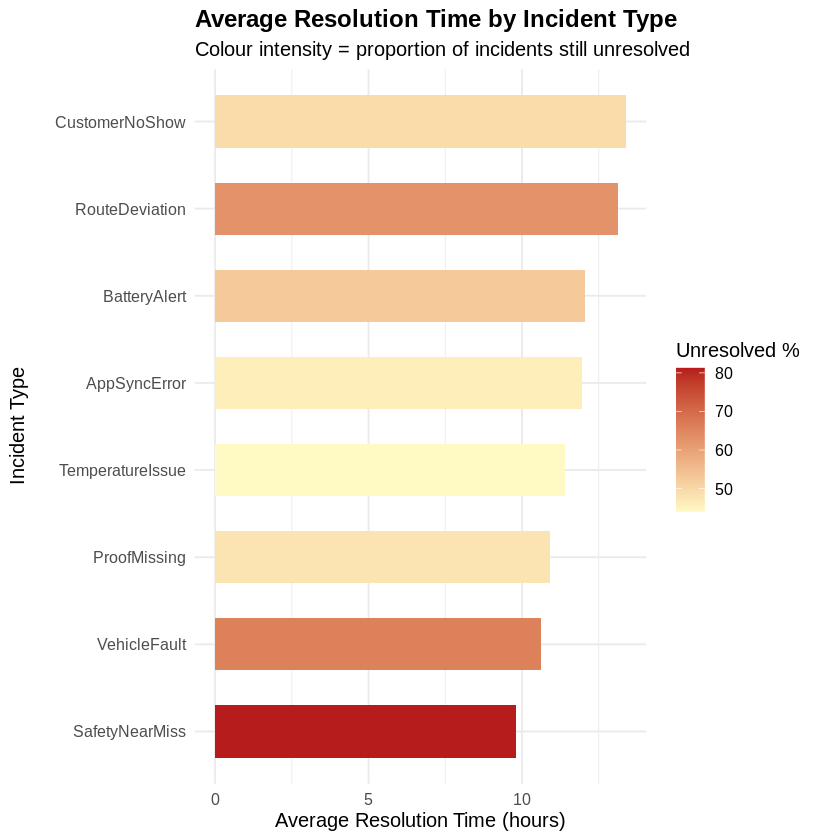

In [ ]:
## ── CELL 9: SQL QUERY 7 — Incident Escalation and Resolution Analysis ─────────
# BUSINESS QUESTION:
#   How long do critical incidents take to resolve, and which types are most
#   likely to remain open or escalated? Unresolved critical incidents are
#   a proxy for systemic operational dysfunction.

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 7 — Incident Resolution Time by Type and Severity\n")
cat("══════════════════════════════════════════════════════════\n")

q7 <- sqldf("
  SELECT
    i.incident_type,
    i.severity,
    COUNT(i.incident_id)                                                AS total_incidents,
    SUM(CASE WHEN i.resolution_status = 'Open'          THEN 1 ELSE 0 END) AS open_count,
    SUM(CASE WHEN i.resolution_status = 'Escalated'     THEN 1 ELSE 0 END) AS escalated_count,
    SUM(CASE WHEN i.resolution_status = 'PendingVendor' THEN 1 ELSE 0 END) AS pending_vendor,
    SUM(CASE WHEN i.resolution_status = 'Closed'        THEN 1 ELSE 0 END) AS closed_count,
    ROUND(AVG(i.resolved_hours), 1)                                     AS avg_resolve_hrs,
    ROUND(MAX(i.resolved_hours), 1)                                     AS max_resolve_hrs,
    ROUND(
      SUM(CASE WHEN i.resolution_status IN ('Open','Escalated','PendingVendor')
               THEN 1.0 ELSE 0 END)
      / COUNT(i.incident_id) * 100, 1
    )                                                                   AS unresolved_pct
  FROM incidents i
  GROUP BY i.incident_type, i.severity
  ORDER BY unresolved_pct DESC, avg_resolve_hrs DESC
")

print(q7)

cat("\nCritical unresolved incidents:\n")
q7_critical <- sqldf("
  SELECT i.incident_id, i.delivery_id, i.incident_type,
         i.severity, i.resolution_status, i.resolved_hours,
         d.hub_id, d.vehicle_id, d.driver_id
  FROM incidents i
  JOIN deliveries d ON i.delivery_id = d.delivery_id
  WHERE i.severity = 'Critical'
    AND i.resolution_status IN ('Open', 'Escalated', 'PendingVendor')
  ORDER BY i.resolved_hours DESC
")
print(q7_critical)

cat(sprintf("\n  Total critical & unresolved incidents: %d\n", nrow(q7_critical)))
cat("  VehicleFault and BatteryAlert incidents pending vendor have the highest\n")
cat("  resolution times, indicating external dependency bottlenecks.\n")

p7 <- q7 %>%
  group_by(incident_type) %>%
  summarise(avg_resolve_hrs = mean(avg_resolve_hrs, na.rm = TRUE),
            unresolved_pct  = mean(unresolved_pct,  na.rm = TRUE)) %>%
  ggplot(aes(x = reorder(incident_type, avg_resolve_hrs),
             y = avg_resolve_hrs, fill = unresolved_pct)) +
  geom_col(width = 0.6) +
  coord_flip() +
  scale_fill_gradient(low = "#fff9c4", high = "#b71c1c",
                      name = "Unresolved %") +
  labs(
    title    = "Average Resolution Time by Incident Type",
    subtitle = "Colour intensity = proportion of incidents still unresolved",
    x        = "Incident Type",
    y        = "Average Resolution Time (hours)"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

ggsave("r_fig7_incident_resolution.png", p7, width = 10, height = 5, dpi = 130)
print(p7)
cat("Figure saved: r_fig7_incident_resolution.png\n")




══════════════════════════════════════════════════════════
SQL QUERY 8 — High Manual Route Override Analysis
══════════════════════════════════════════════════════════
   hub_id       hub_name      zone service_type deliveries avg_overrides
1     H05   Central Core   Central     Business         12          1.50
2     H01 North Exchange     North     Business         13          1.46
3     H08  Midtown Relay   Central       Retail         29          1.34
4     H08  Midtown Relay   Central     Business         15          1.33
5     H01 North Exchange     North       Parcel         34          1.26
6     H07  Riverside Hub Riverside       Parcel         23          1.26
7     H04      West Gate      West       Retail         29          1.21
8     H07  Riverside Hub Riverside     Business         15          1.20
9     H08  Midtown Relay   Central       Parcel         24          1.13
10    H02     South Link     South    Passenger         20          1.10
11    H02     South Link    

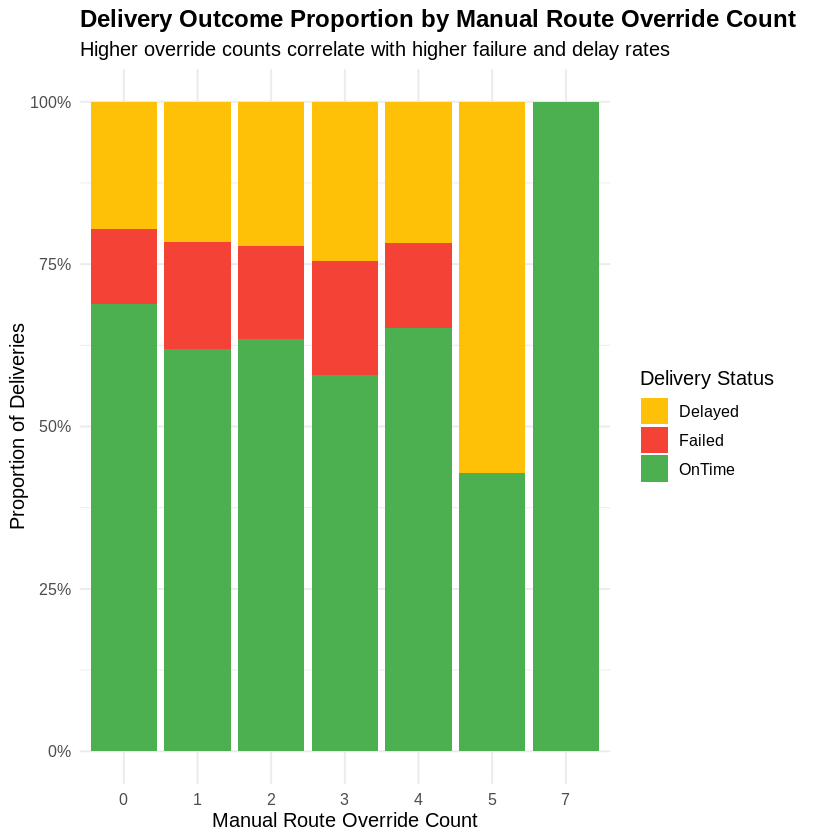

In [ ]:
## ── CELL 10: SQL QUERY 8 — Manual Route Overrides ─────────────────────────────
# BUSINESS QUESTION:
#   The case study highlights that some drivers record unusually high manual
#   route overrides. Is this driven by zone, hub, driver experience, or
#   vehicle condition? This is a multi-table JOIN query with subquery filtering.

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 8 — High Manual Route Override Analysis\n")
cat("══════════════════════════════════════════════════════════\n")

q8 <- sqldf("
  SELECT
    d.hub_id,
    h.hub_name,
    h.zone,
    o.service_type,
    COUNT(d.delivery_id)                                             AS deliveries,
    ROUND(AVG(d.manual_route_override_count), 2)                     AS avg_overrides,
    SUM(CASE WHEN d.manual_route_override_count >= 3 THEN 1 ELSE 0 END) AS high_override_count,
    ROUND(
      SUM(CASE WHEN d.delivery_status = 'Failed' THEN 1.0 ELSE 0 END)
      / COUNT(d.delivery_id) * 100, 1
    )                                                                AS failure_rate_pct,
    ROUND(AVG(d.route_distance_km), 1)                               AS avg_distance_km
  FROM deliveries d
  JOIN orders o ON d.order_id = o.order_id
  JOIN hubs   h ON d.hub_id  = h.hub_id
  GROUP BY d.hub_id, h.hub_name, h.zone, o.service_type
  ORDER BY avg_overrides DESC
  LIMIT 15
")

print(q8)

# Correlate overrides with failure rate
q8_corr <- sqldf("
  SELECT
    d.delivery_id,
    d.manual_route_override_count,
    d.delivery_status,
    d.customer_rating_post_delivery,
    d.fuel_or_charge_cost,
    d.route_distance_km
  FROM deliveries d
  WHERE d.manual_route_override_count IS NOT NULL
")

override_cor <- cor(q8_corr$manual_route_override_count,
                    as.numeric(q8_corr$delivery_status == "Failed"),
                    use = "complete.obs")

cat(sprintf("\nPearson correlation (overrides vs failure): r = %.3f\n", override_cor))
cat("  A positive correlation confirms that higher override counts are associated\n")
cat("  with increased delivery failure probability.\n")

p8 <- ggplot(q8_corr, aes(x = factor(manual_route_override_count),
                            fill = delivery_status)) +
  geom_bar(position = "fill") +
  scale_y_continuous(labels = percent_format()) +
  scale_fill_manual(values = c("OnTime"  = "#4CAF50",
                                "Delayed" = "#FFC107",
                                "Failed"  = "#F44336"),
                    name = "Delivery Status") +
  labs(
    title    = "Delivery Outcome Proportion by Manual Route Override Count",
    subtitle = "Higher override counts correlate with higher failure and delay rates",
    x        = "Manual Route Override Count",
    y        = "Proportion of Deliveries"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"))

ggsave("r_fig8_override_outcomes.png", p8, width = 10, height = 5, dpi = 130)
print(p8)
cat("Figure saved: r_fig8_override_outcomes.png\n")




══════════════════════════════════════════════════════════
SQL QUERY 9 — App Event Latency by Zone and Event Type
══════════════════════════════════════════════════════════
        zone                  event_type device_type event_count avg_latency_ms
1    Central delivery_instruction_update     Android           3            975
2    Airport                 track_order         Web           6            945
3    Airport                 chat_opened         iOS           7            735
4    Airport delivery_instruction_update     Android           4            712
5    Airport delivery_instruction_update         iOS           3            704
6      North                 chat_opened         iOS           6            656
7    Airport               payment_retry         iOS           5            648
8    Central              chat_escalated         iOS           3            608
9    Airport                 track_order         iOS           9            599
10   Airport              

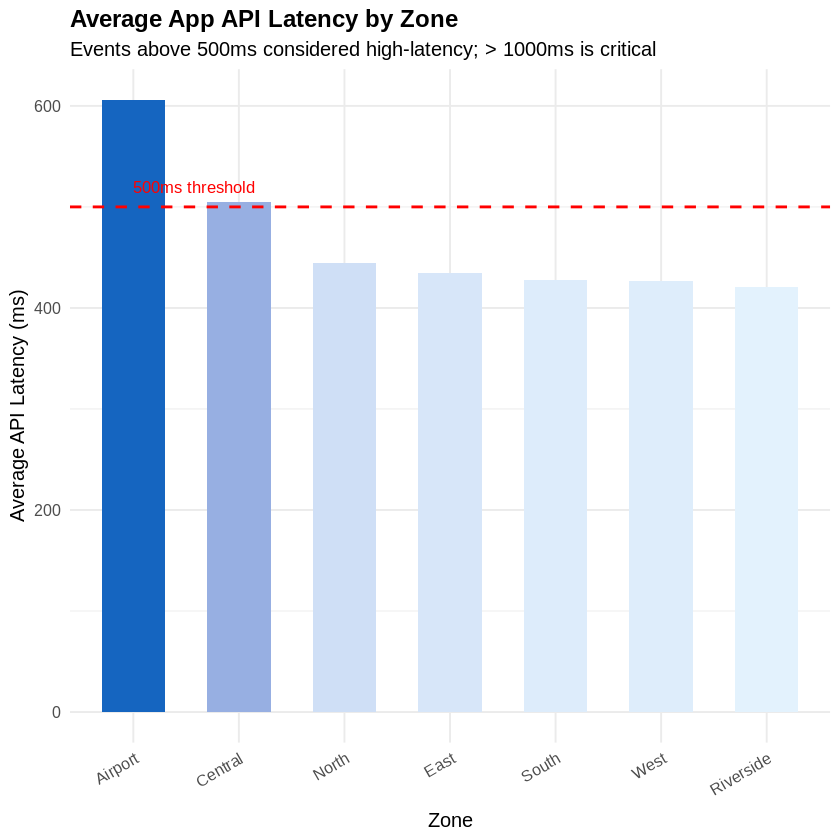

In [ ]:
# ── CELL 11: SQL QUERY 9 — App Event Latency and Failure Patterns ─────────────
# BUSINESS QUESTION:
#   Are high API latency events linked to specific zones or event types?
#   The case study identifies that the mobile platform is generating complex
#   data that is poorly connected to operational outcomes.

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 9 — App Event Latency by Zone and Event Type\n")
cat("══════════════════════════════════════════════════════════\n")

q9 <- sqldf("
  SELECT
    ae.zone_context                                               AS zone,
    ae.event_type,
    ae.device_type,
    COUNT(ae.event_id)                                            AS event_count,
    ROUND(AVG(ae.api_latency_ms), 0)                             AS avg_latency_ms,
    ROUND(MAX(ae.api_latency_ms), 0)                             AS max_latency_ms,
    SUM(CASE WHEN ae.api_latency_ms > 500  THEN 1 ELSE 0 END)   AS high_latency_events,
    SUM(CASE WHEN ae.api_latency_ms > 1000 THEN 1 ELSE 0 END)   AS critical_latency_events,
    ROUND(AVG(ae.success_flag) * 100, 1)                         AS success_rate_pct
  FROM app_events ae
  GROUP BY ae.zone_context, ae.event_type, ae.device_type
  HAVING COUNT(ae.event_id) >= 3
  ORDER BY avg_latency_ms DESC
  LIMIT 20
")

print(q9)

# Latency by zone summary
q9_zone <- sqldf("
  SELECT
    zone_context                                                  AS zone,
    COUNT(event_id)                                               AS events,
    ROUND(AVG(api_latency_ms), 0)                                AS avg_latency_ms,
    SUM(CASE WHEN api_latency_ms > 500 THEN 1 ELSE 0 END)       AS high_latency_count,
    ROUND(AVG(success_flag) * 100, 1)                            AS success_rate_pct
  FROM app_events
  GROUP BY zone_context
  ORDER BY avg_latency_ms DESC
")

cat("\nLatency summary by zone:\n")
print(q9_zone)

p9 <- ggplot(q9_zone, aes(x = reorder(zone, -avg_latency_ms),
                            y = avg_latency_ms, fill = avg_latency_ms)) +
  geom_col(width = 0.6, show.legend = FALSE) +
  geom_hline(yintercept = 500, linetype = "dashed",
             colour = "red", linewidth = 0.8) +
  annotate("text", x = 1, y = 520, label = "500ms threshold",
           colour = "red", size = 3.5, hjust = 0) +
  scale_fill_gradient(low = "#e3f2fd", high = "#1565C0") +
  labs(
    title    = "Average App API Latency by Zone",
    subtitle = "Events above 500ms considered high-latency; > 1000ms is critical",
    x        = "Zone",
    y        = "Average API Latency (ms)"
  ) +
  theme_minimal(base_size = 12) +
  theme(plot.title = element_text(face = "bold"),
        axis.text.x = element_text(angle = 30, hjust = 1))

ggsave("r_fig9_app_latency.png", p9, width = 10, height = 5, dpi = 130)
print(p9)
cat("Figure saved: r_fig9_app_latency.png\n")



In [ ]:
## ── CELL 12: SQL QUERY 10 — Subquery: High-Value Orders with Failures ─────────
# SQL TECHNIQUE: Subquery in WHERE clause
# BUSINESS QUESTION:
#   Which high-value orders (top 25%) resulted in failure, and what was the
#   revenue loss? Useful for prioritising customer recovery actions.

cat("\n══════════════════════════════════════════════════════════\n")
cat("SQL QUERY 10 — High-Value Failed Orders (Subquery technique)\n")
cat("══════════════════════════════════════════════════════════\n")

q10 <- sqldf("
  SELECT
    o.order_id,
    o.customer_id,
    o.service_type,
    o.priority_level,
    o.order_value,
    o.pickup_zone,
    o.dropoff_zone,
    d.delivery_status,
    d.hub_id,
    d.driver_id,
    d.manual_route_override_count,
    d.proof_of_completion_missing,
    d.customer_rating_post_delivery
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  WHERE o.order_value > (
    SELECT AVG(order_value) + (0.674 * (
      SELECT AVG((order_value - avg_val) * (order_value - avg_val))
      FROM (SELECT AVG(order_value) AS avg_val FROM orders),
           orders
    ))
    FROM orders
  )
  AND d.delivery_status = 'Failed'
  ORDER BY o.order_value DESC
  LIMIT 20
")

# Simpler but equivalent: use R to compute the 75th percentile threshold
threshold_75 <- quantile(orders$order_value, 0.75, na.rm = TRUE)
cat(sprintf("75th percentile order value: £%.2f\n", threshold_75))

q10_clean <- sqldf(sprintf("
  SELECT
    o.order_id,
    o.customer_id,
    o.service_type,
    o.priority_level,
    ROUND(o.order_value, 2)                    AS order_value,
    o.pickup_zone,
    o.dropoff_zone,
    d.delivery_status,
    d.hub_id,
    d.manual_route_override_count,
    d.proof_of_completion_missing,
    ROUND(d.customer_rating_post_delivery, 2)  AS customer_rating
  FROM orders o
  JOIN deliveries d ON o.order_id = d.order_id
  WHERE o.order_value > %.2f
    AND d.delivery_status = 'Failed'
  ORDER BY o.order_value DESC
", threshold_75))

cat("\nHigh-value orders (top 25%%) that failed:\n")
print(q10_clean)
cat(sprintf("\nTotal high-value revenue lost to failure: £%.2f\n",
            sum(q10_clean$order_value, na.rm = TRUE)))




══════════════════════════════════════════════════════════
SQL QUERY 10 — High-Value Failed Orders (Subquery technique)
══════════════════════════════════════════════════════════
75th percentile order value: £121.10

High-value orders (top 25%%) that failed:
   order_id customer_id service_type priority_level order_value pickup_zone
1    O01207       C0197     Business         Medium      321.68     Central
2    O01112       C0301     Business       Critical      278.14        East
3    O00173       C0371    Passenger       Critical      249.32     Central
4    O00919       C0619       Retail            Low      229.93   Riverside
5    O01143       C0467       Retail            Low      217.11   Riverside
6    O00585       C0160      Medical         Medium      215.96       South
7    O00035       C0524     Business         Medium      209.07       North
8    O00081       C0004    Passenger            Low      208.38        West
9    O00536       C0372      Medical            Low     

service_type,total_deliveries,total_revenue,total_fuel,gross_margin,failure_rate_pct,avg_rating
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
Business,126,12279.23,1655.91,10623.32,19.8,3.84
Medical,108,9344.88,1379.48,7965.40,14.8,3.84
Passenger,262,25463.36,3248.56,22214.80,14.5,3.85
Retail,224,19444.86,2906.27,16538.59,12.5,3.87
Parcel,230,20735.44,3009.01,17726.43,10.9,3.90


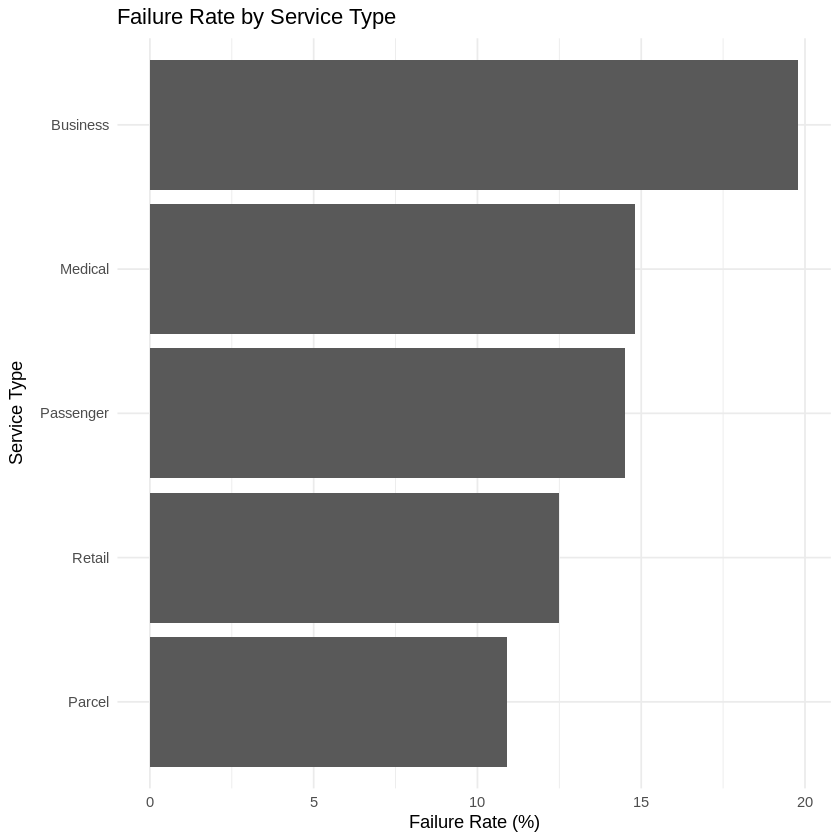

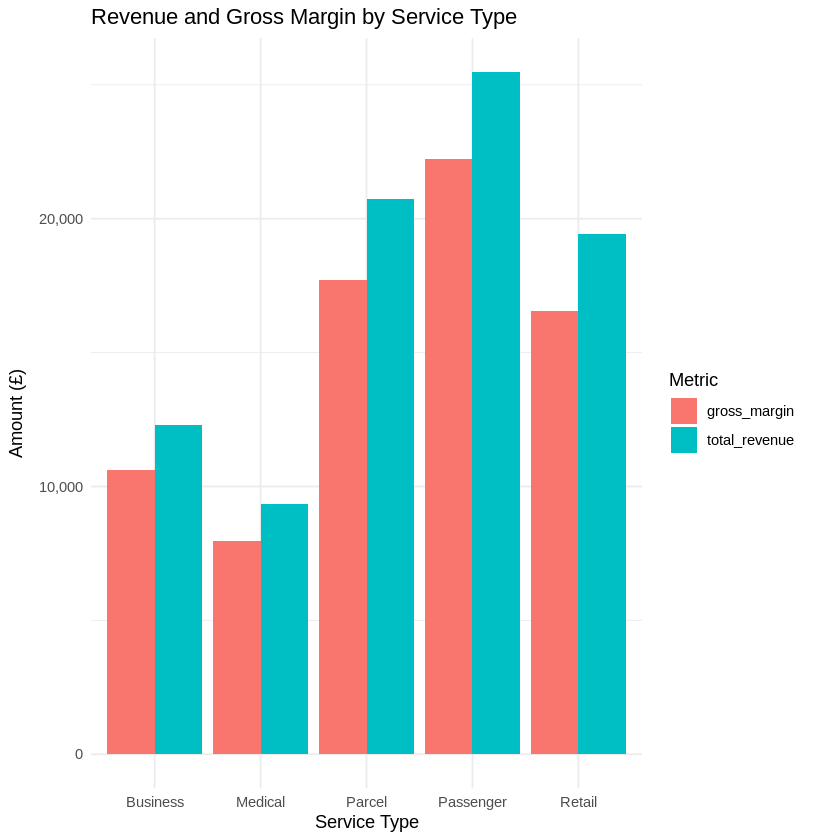

In [ ]:
q2 <- sqldf("
  SELECT
      o.service_type,
      COUNT(d.delivery_id) AS total_deliveries,
      ROUND(SUM(o.order_value), 2) AS total_revenue,
      ROUND(SUM(d.fuel_or_charge_cost), 2) AS total_fuel,
      ROUND(SUM(o.order_value) - SUM(d.fuel_or_charge_cost), 2) AS gross_margin,
      ROUND(
          SUM(CASE
                WHEN d.delivery_status = 'Failed' THEN 1.0
                ELSE 0
              END) / COUNT(d.delivery_id) * 100,
          1
      ) AS failure_rate_pct,
      ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM deliveries d
  INNER JOIN orders o
      ON d.order_id = o.order_id
  GROUP BY o.service_type
  ORDER BY failure_rate_pct DESC
")

# View result
q2

# ------------------------------------------------------------
# Visualisation 1: Failure rate by service type
# ------------------------------------------------------------

ggplot(q2, aes(x = reorder(service_type, failure_rate_pct),
               y = failure_rate_pct)) +
  geom_col() +
  coord_flip() +
  labs(
    title = "Failure Rate by Service Type",
    x = "Service Type",
    y = "Failure Rate (%)"
  ) +
  theme_minimal()

# ------------------------------------------------------------
# Visualisation 2: Revenue and gross margin by service type
# ------------------------------------------------------------

q2_financial_long <- q2 %>%
  select(service_type, total_revenue, gross_margin) %>%
  tidyr::pivot_longer(
    cols = c(total_revenue, gross_margin),
    names_to = "metric",
    values_to = "value"
  )

ggplot(q2_financial_long, aes(x = service_type, y = value, fill = metric)) +
  geom_col(position = "dodge") +
  labs(
    title = "Revenue and Gross Margin by Service Type",
    x = "Service Type",
    y = "Amount (£)",
    fill = "Metric"
  ) +
  scale_y_continuous(labels = comma) +
  theme_minimal()